# EDA — Station 043301 (Des Prairies)

Three data sources:
- **Historical flow** (`flow_m3s`): daily, 1922–present
- **Historical level** (`level_m`): daily, 1971–present
- **Live feed**: 15-minute intervals, rolling ~1 week

Sections:
1. Load & merge
2. Coverage & gaps
3. Full time-series overview
4. Seasonality
5. Flow–level relationship
6. Outliers & data quality
7. Autocorrelation
8. Live feed snapshot

In [1]:
import sys
sys.path.insert(0, 'src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from load_data import load_flow, load_level, load_live

plt.rcParams['figure.figsize'] = (14, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
sns.set_theme(style='whitegrid')

Matplotlib is building the font cache; this may take a moment.


## 1. Load & merge

In [2]:
flow  = load_flow()
level = load_level()
live  = load_live()

# Merge historical sources on date index (outer join to expose gaps)
hist = flow[['flow_m3s', 'remark']].join(
    level[['level_m']],
    how='outer'
)
hist.index.name = 'date'

print(f"Historical: {len(hist):,} rows  |  {hist.index.min().date()} → {hist.index.max().date()}")
print(f"Live:       {len(live):,} rows  |  {live.index.min()} → {live.index.max()}")
hist.tail(3)

Loading from cache: /Users/laurentchouinard/claude/riviere/data/043301_Q.txt


Loaded 37,008 rows from 1922-10-01 to 2026-02-26
Loading from cache: /Users/laurentchouinard/claude/riviere/data/043301_N.txt


Loaded 19,259 rows from 1971-12-21 to 2026-02-26


Loaded 624 live rows from 2026-02-25 00:00:00 to 2026-03-03 11:45:00
Historical: 37,769 rows  |  1922-10-01 → 2026-02-26
Live:       624 rows  |  2026-02-25 00:00:00 → 2026-03-03 11:45:00


,flow_m3s,remark,level_m
date,,,
2026-02-24,911.0,P,47.63
2026-02-25,939.0,P,47.67
2026-02-26,927.2,P,47.65


## 2. Coverage & gaps

In [3]:
print("=== Null counts ===")
print(hist.isnull().sum())
print()

# Expected daily index
full_idx = pd.date_range(hist.index.min(), hist.index.max(), freq='D')
missing_dates = full_idx.difference(hist.index)
print(f"Missing dates in index: {len(missing_dates)}")
if len(missing_dates) > 0:
    print(missing_dates[:10])

print()
print("=== Remark distribution ===")
print(hist['remark'].value_counts(dropna=False).head(10))

=== Null counts ===
flow_m3s      761
remark        761
level_m     18510
dtype: int64

Missing dates in index: 1
DatetimeIndex(['2024-04-24'], dtype='datetime64[us]', freq='D')

=== Remark distribution ===
remark
MC     22638
MJ      7324
R       6789
NaN      761
J         99
P         85
E         54
S         19
Name: count, dtype: int64


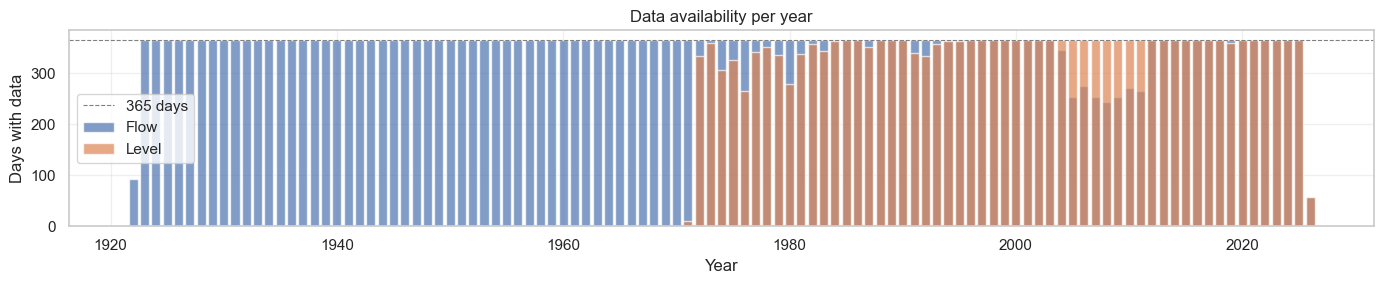

In [4]:
# Visualise data availability per year
hist['year'] = hist.index.year
availability = hist.groupby('year').agg(
    flow_days  = ('flow_m3s',  'count'),
    level_days = ('level_m',   'count'),
)

fig, ax = plt.subplots(figsize=(14, 3))
ax.bar(availability.index, availability['flow_days'],  label='Flow',  alpha=0.7)
ax.bar(availability.index, availability['level_days'], label='Level', alpha=0.7)
ax.axhline(365, color='gray', linestyle='--', linewidth=0.8, label='365 days')
ax.set_xlabel('Year')
ax.set_ylabel('Days with data')
ax.set_title('Data availability per year')
ax.legend()
plt.tight_layout()
plt.show()

hist.drop(columns='year', inplace=True)

## 3. Full time-series overview

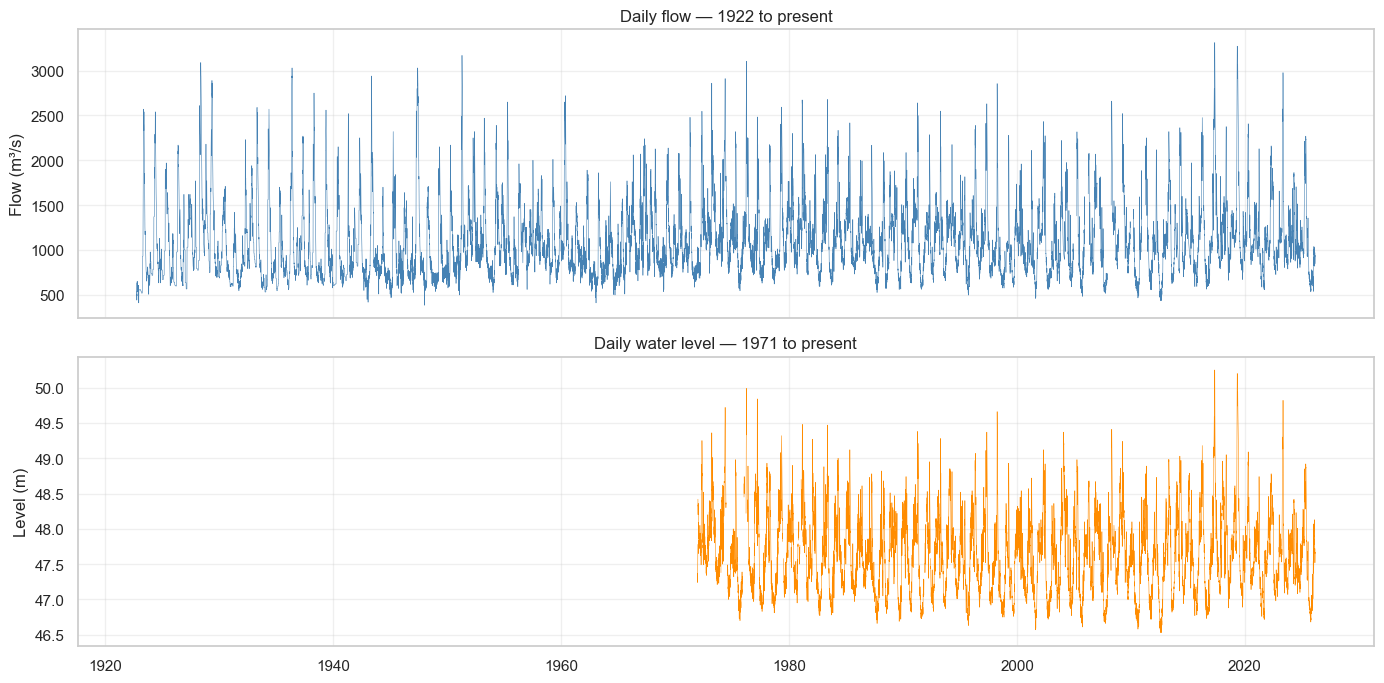

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(hist.index, hist['flow_m3s'], linewidth=0.4, color='steelblue')
axes[0].set_ylabel('Flow (m³/s)')
axes[0].set_title('Daily flow — 1922 to present')

axes[1].plot(hist.index, hist['level_m'], linewidth=0.4, color='darkorange')
axes[1].set_ylabel('Level (m)')
axes[1].set_title('Daily water level — 1971 to present')

plt.tight_layout()
plt.show()

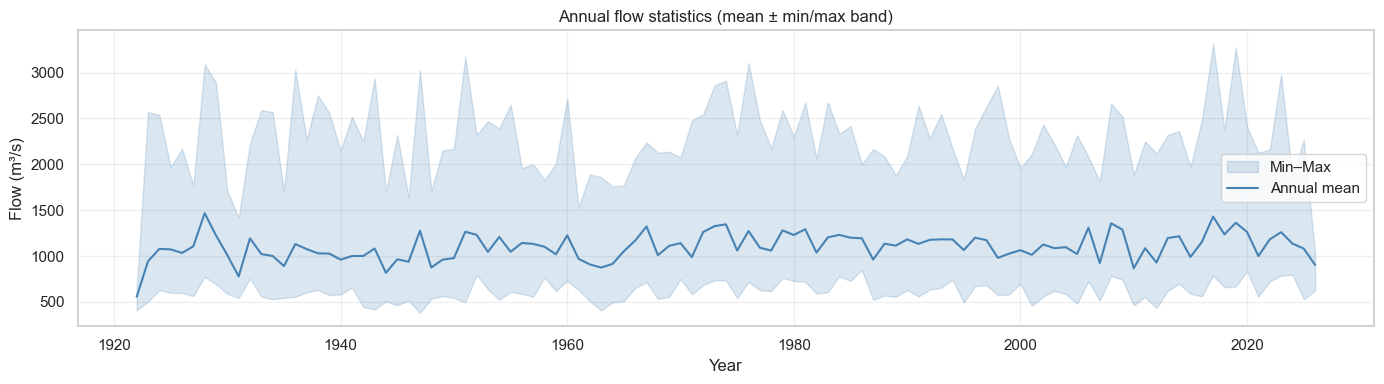

In [6]:
# Annual statistics
annual = hist.groupby(hist.index.year).agg(
    flow_mean = ('flow_m3s', 'mean'),
    flow_max  = ('flow_m3s', 'max'),
    flow_min  = ('flow_m3s', 'min'),
)

fig, ax = plt.subplots(figsize=(14, 4))
ax.fill_between(annual.index, annual['flow_min'], annual['flow_max'], alpha=0.2, color='steelblue', label='Min–Max')
ax.plot(annual.index, annual['flow_mean'], color='steelblue', linewidth=1.5, label='Annual mean')
ax.set_xlabel('Year')
ax.set_ylabel('Flow (m³/s)')
ax.set_title('Annual flow statistics (mean ± min/max band)')
ax.legend()
plt.tight_layout()
plt.show()

## 4. Seasonality

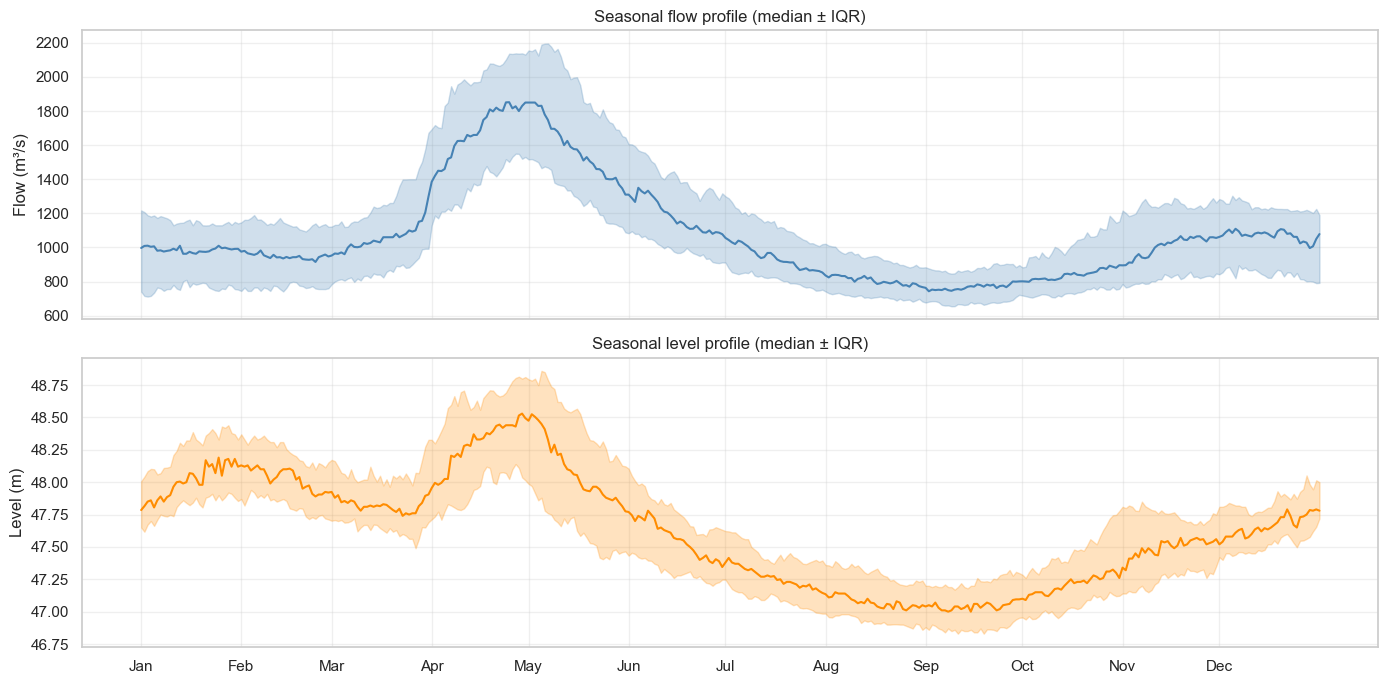

In [7]:
# Day-of-year seasonal profile (median ± IQR)
hist['doy'] = hist.index.day_of_year

seasonal_flow = hist.groupby('doy')['flow_m3s'].agg(
    median='median', q25=lambda x: x.quantile(0.25), q75=lambda x: x.quantile(0.75)
)
seasonal_level = hist.groupby('doy')['level_m'].agg(
    median='median', q25=lambda x: x.quantile(0.25), q75=lambda x: x.quantile(0.75)
)

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

for ax, df, ylabel, color, title in [
    (axes[0], seasonal_flow,  'Flow (m³/s)', 'steelblue',  'Seasonal flow profile (median ± IQR)'),
    (axes[1], seasonal_level, 'Level (m)',   'darkorange', 'Seasonal level profile (median ± IQR)'),
]:
    ax.fill_between(df.index, df['q25'], df['q75'], alpha=0.25, color=color)
    ax.plot(df.index, df['median'], color=color, linewidth=1.5)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    # Label months on x-axis
    month_starts = [1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335]
    month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
    ax.set_xticks(month_starts)
    ax.set_xticklabels(month_labels)

plt.tight_layout()
plt.show()

hist.drop(columns='doy', inplace=True)

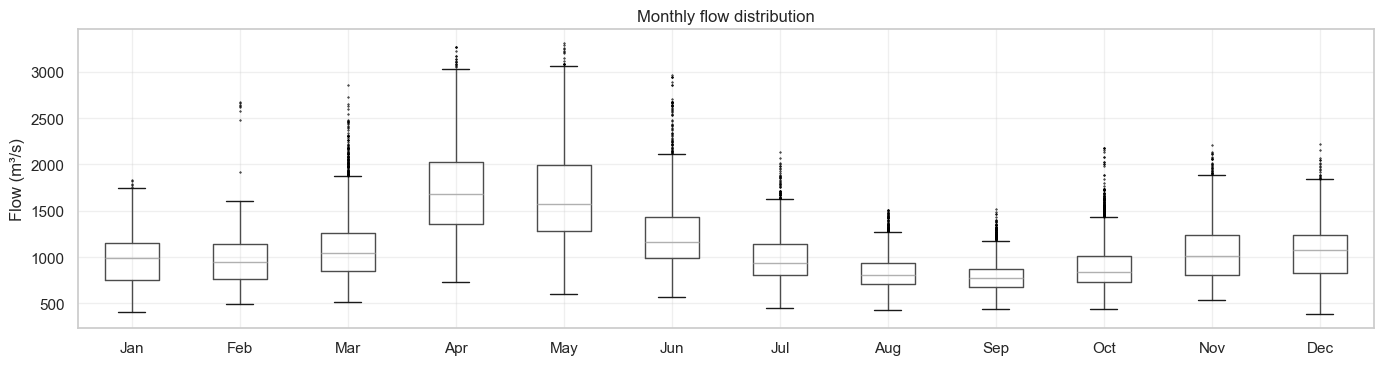

In [8]:
# Monthly box plots
hist['month'] = hist.index.month
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(14, 4))
hist.boxplot(column='flow_m3s', by='month', ax=ax, flierprops=dict(marker='.', markersize=1))
ax.set_xticklabels(month_labels)
ax.set_xlabel('')
ax.set_ylabel('Flow (m³/s)')
ax.set_title('Monthly flow distribution')
fig.suptitle('')
plt.tight_layout()
plt.show()

hist.drop(columns='month', inplace=True)

## 5. Flow–level relationship

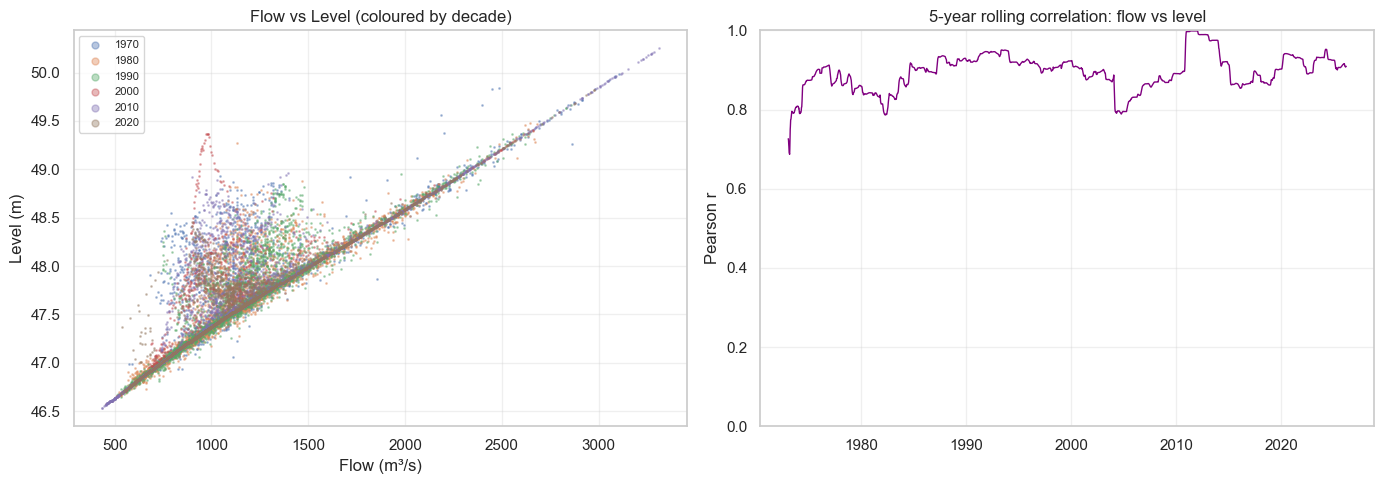

Overall Pearson r (flow vs level): 0.8972


In [9]:
both = hist.dropna(subset=['flow_m3s', 'level_m'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter coloured by decade
both = both.copy()
both['decade'] = (both.index.year // 10) * 10
for decade, grp in both.groupby('decade'):
    axes[0].scatter(grp['flow_m3s'], grp['level_m'], s=1, alpha=0.4, label=str(decade))
axes[0].set_xlabel('Flow (m³/s)')
axes[0].set_ylabel('Level (m)')
axes[0].set_title('Flow vs Level (coloured by decade)')
axes[0].legend(markerscale=5, fontsize=8)

# Pearson correlation over time (10-year rolling)
rolling_corr = both['flow_m3s'].rolling(365 * 5, min_periods=365).corr(both['level_m'])
axes[1].plot(rolling_corr.index, rolling_corr, color='purple', linewidth=1)
axes[1].set_ylabel('Pearson r')
axes[1].set_title('5-year rolling correlation: flow vs level')
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

print(f"Overall Pearson r (flow vs level): {both['flow_m3s'].corr(both['level_m']):.4f}")

## 6. Outliers & data quality

In [10]:
# Z-score based outlier detection
from scipy import stats

for col in ['flow_m3s', 'level_m']:
    s = hist[col].dropna()
    z = np.abs(stats.zscore(s))
    outliers = s[z > 4]
    print(f"{col}: {len(outliers)} values with |z| > 4")
    if len(outliers) > 0:
        print(outliers.sort_values(ascending=False).head(10))
    print()

flow_m3s: 136 values with |z| > 4
date
2017-05-08    3313.0
2017-05-09    3287.0
2019-04-29    3273.0
2019-04-30    3268.0
2019-04-28    3268.0
2017-05-07    3256.0
2019-05-01    3246.0
2019-05-02    3228.0
2019-04-27    3226.0
2017-05-10    3220.0
Name: flow_m3s, dtype: float64

level_m: 26 values with |z| > 4
date
2017-05-08    50.25
2017-05-09    50.21
2019-04-29    50.20
2019-04-28    50.19
2019-04-30    50.19
2017-05-07    50.18
2019-05-01    50.16
2019-05-02    50.14
2019-04-27    50.14
2017-05-10    50.13
Name: level_m, dtype: float64



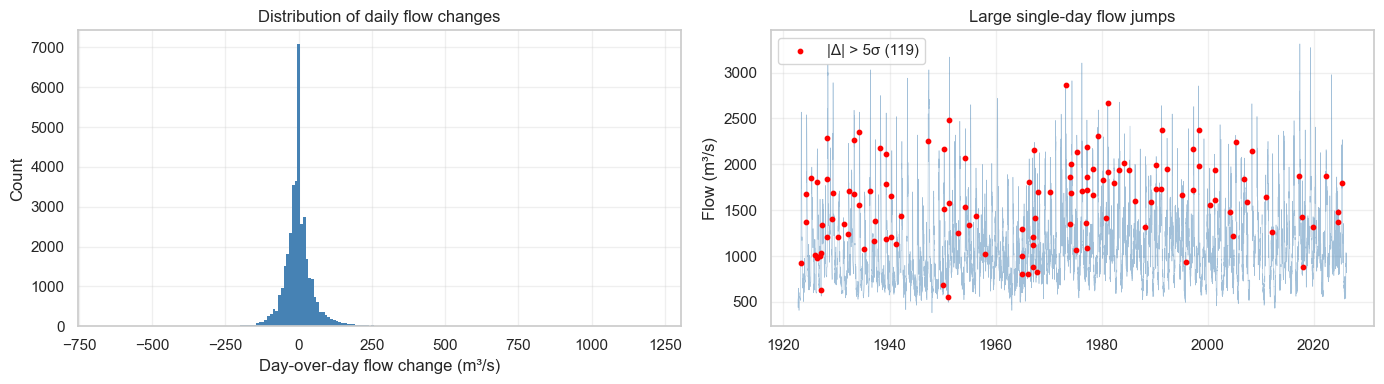

Large jumps (|Δ| > 5σ = 283 m³/s): 119


In [11]:
# Day-over-day change distribution
flow_diff = hist['flow_m3s'].diff().dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(flow_diff, bins=200, color='steelblue', edgecolor='none')
axes[0].set_xlabel('Day-over-day flow change (m³/s)')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of daily flow changes')

# Flag large single-day jumps
threshold = flow_diff.std() * 5
large_jumps = flow_diff[flow_diff.abs() > threshold]
axes[1].plot(hist.index, hist['flow_m3s'], linewidth=0.4, color='steelblue', alpha=0.5)
axes[1].scatter(large_jumps.index, hist.loc[large_jumps.index, 'flow_m3s'],
                color='red', s=10, zorder=5, label=f'|Δ| > 5σ ({len(large_jumps)})')
axes[1].set_ylabel('Flow (m³/s)')
axes[1].set_title('Large single-day flow jumps')
axes[1].legend()

plt.tight_layout()
plt.show()
print(f"Large jumps (|Δ| > 5σ = {threshold:.0f} m³/s): {len(large_jumps)}")

## 7. Autocorrelation

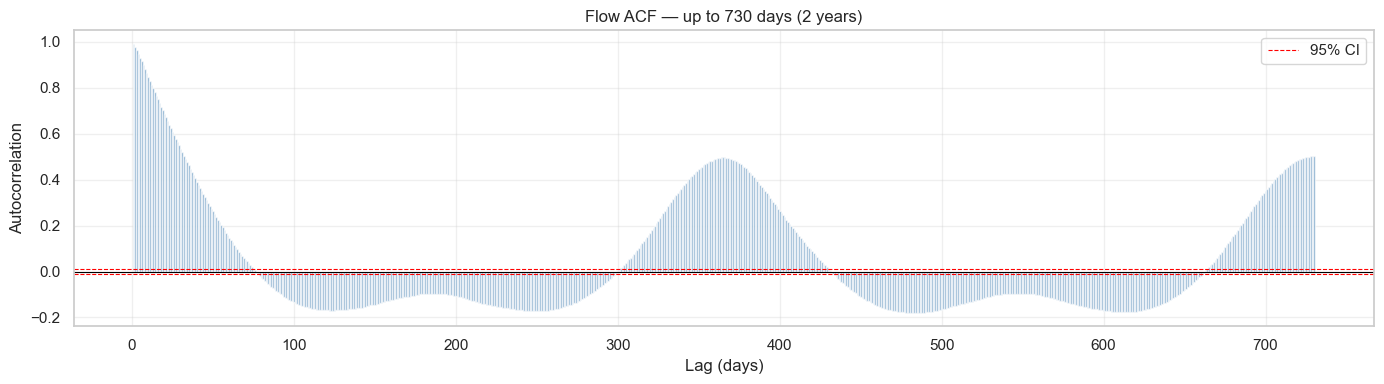

ACF at key lags:
  lag=  1d: 0.9911
  lag=  2d: 0.9776
  lag=  3d: 0.9628
  lag=  5d: 0.9310
  lag=  7d: 0.8980
  lag= 14d: 0.7821
  lag= 30d: 0.5336
  lag= 60d: 0.1478
  lag= 90d: -0.0883
  lag=180d: -0.0979
  lag=365d: 0.4971


In [12]:
from pandas.plotting import autocorrelation_plot

flow_clean = hist['flow_m3s'].dropna()

# Manual ACF up to 730 lags (2 years)
max_lag = 730
acf_vals = [flow_clean.autocorr(lag=k) for k in range(1, max_lag + 1)]

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(range(1, max_lag + 1), acf_vals, width=1, color='steelblue', alpha=0.7)
ax.axhline(0, color='black', linewidth=0.8)
# 95% confidence band
ci = 1.96 / np.sqrt(len(flow_clean))
ax.axhline( ci, color='red', linestyle='--', linewidth=0.8, label='95% CI')
ax.axhline(-ci, color='red', linestyle='--', linewidth=0.8)
ax.set_xlabel('Lag (days)')
ax.set_ylabel('Autocorrelation')
ax.set_title('Flow ACF — up to 730 days (2 years)')
ax.legend()
plt.tight_layout()
plt.show()

# Print ACF at key lags
key_lags = [1, 2, 3, 5, 7, 14, 30, 60, 90, 180, 365]
print("ACF at key lags:")
for lag in key_lags:
    print(f"  lag={lag:3d}d: {flow_clean.autocorr(lag=lag):.4f}")

## 8. Live feed snapshot

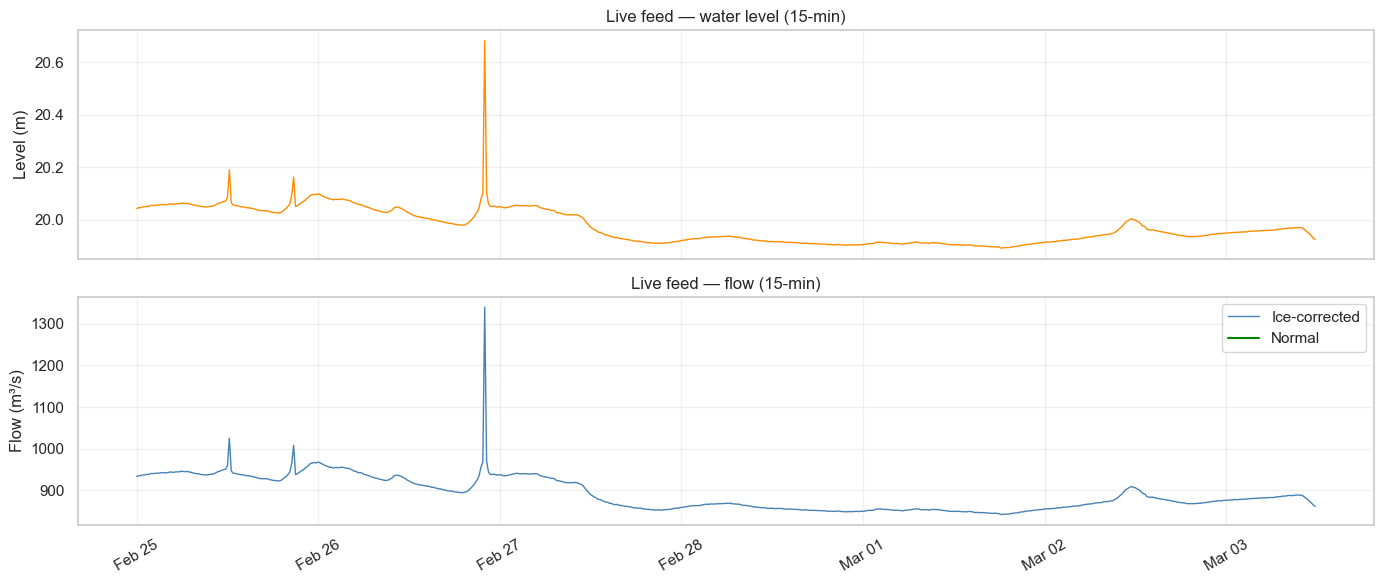

       level_m  flow_m3s
count   624.00    624.00
mean     19.97    890.99
std       0.07     41.81
min      19.89    841.50
25%      19.92    855.65
50%      19.95    877.40
75%      20.04    929.45
max      20.68   1340.00


In [13]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

axes[0].plot(live.index, live['level_m'], color='darkorange', linewidth=1)
axes[0].set_ylabel('Level (m)')
axes[0].set_title('Live feed — water level (15-min)')

# Mark ice-corrected points
ice = live[live['ice_corrected']]
not_ice = live[~live['ice_corrected']]
axes[1].plot(ice.index,     ice['flow_m3s'],     color='steelblue', linewidth=1,   label='Ice-corrected')
axes[1].plot(not_ice.index, not_ice['flow_m3s'], color='green',     linewidth=1.5, label='Normal')
axes[1].set_ylabel('Flow (m³/s)')
axes[1].set_title('Live feed — flow (15-min)')
axes[1].legend()

axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

print(live.describe().round(2))

## Summary statistics

In [14]:
print("=== Historical flow (m³/s) ===")
print(hist['flow_m3s'].describe().round(1))
print()
print("=== Historical level (m) ===")
print(hist['level_m'].describe().round(3))
print()
print(f"Peak flow:  {hist['flow_m3s'].max():.0f} m³/s on {hist['flow_m3s'].idxmax().date()}")
print(f"Peak level: {hist['level_m'].max():.3f} m on {hist['level_m'].idxmax().date()}")
print(f"Min flow:   {hist['flow_m3s'].min():.0f} m³/s on {hist['flow_m3s'].idxmin().date()}")

=== Historical flow (m³/s) ===
count    37008.0
mean      1106.1
std        425.0
min        382.0
25%        799.0
50%       1010.0
75%       1296.0
max       3313.0
Name: flow_m3s, dtype: float64

=== Historical level (m) ===
count    19259.000
mean        47.653
std          0.560
min         46.530
25%         47.220
50%         47.610
75%         47.990
max         50.250
Name: level_m, dtype: float64

Peak flow:  3313 m³/s on 2017-05-08
Peak level: 50.250 m on 2017-05-08
Min flow:   382 m³/s on 1947-12-30
